In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

from superfv import HydroSolver, TimeIntegrator
import superfv.initial_conditions as superic
from spd.sdfb_simulator import SDFB_Simulator
import spd.initial_conditions as spdic
from spd.finite_volume.muscl import Slope_limiter as spd_muscl_limiter

In [2]:
NDOF = 128
p = 7
T = 1.0

In [3]:
super_sim = HydroSolver(
    ic=partial(superic.square, vx=1.0, vy=1.0),
    nx=NDOF,
    ny=NDOF,
    p=p,
    gamma=1.4,
    use_MOOD=True,
    rtol=1e-5,
    use_SED=True,
    cupy=True,
)
super_sim.run(T, time_integrator=TimeIntegrator.SSPRK3)

SuperFV: 699 steps | t=1.00e+00/1.00e+00, dt=9.21e-04 | rho_min=1.00e+00 | E_cons=0.00e+00 | wall=1.22e+01s (done)


In [4]:
N = NDOF // (p + 1)

spd_sim = SDFB_Simulator(
    p=p,
    N=(N, N),
    init_fct=spdic.step_function(),
    cfl_coeff=0.4,
    use_cupy=True,
    time_integrator="rk3",
    gamma=1.4,
    scheme="SDFB",
    riemann_solver_sd="hllc",  # SD high-order flux
    riemann_solver_fv="hllc",  # MUSCL fallback flux
    fallback="MUSCL",  # plain MUSCL fallback, not MUSCL-Hancock
    FB=True,
    tolerance=1e-5,
    NAD="",
    PAD=True,
    SED=True,
)
spd_sim.lo_scheme.slope_limiter = spd_muscl_limiter("moncen")
spd_sim.perform_time_evolution(T)

t=1.0, steps taken 1398, time taken 93.148, bzcps = 0.0


In [5]:
x_sp = spd_sim.dm.X_sp.reshape(-1)
y_sp = spd_sim.dm.Y_sp.reshape(-1)

X_sp, Y_sp = np.meshgrid(x_sp, y_sp)

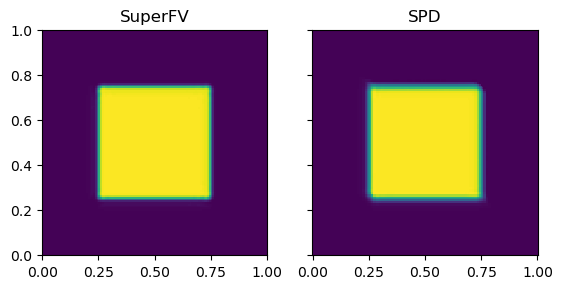

In [8]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
axs[0].set_aspect("equal")
axs[1].set_aspect("equal")

axs[0].set_title("SuperFV")
axs[1].set_title("SPD")

x_fv = super_sim.mesh.get_cell_centers(numpy_copy=True)[0][:, :, 0]
y_fv = super_sim.mesh.get_cell_centers(numpy_copy=True)[1][:, :, 0]
z_fv = super_sim.snapshot_history[-1].u[super_sim.idx("rho"), :, :, 0]

x_sd, y_sd = np.meshgrid(spd_sim.dm.X_sp.reshape(-1), spd_sim.dm.Y_sp.reshape(-1))
z_sd = spd_sim.dm.U_sp[0, ...].transpose(0, 2, 1, 3).reshape(len(x_sd), len(y_sd))

vmin = np.minimum(z_fv, z_sd).min()
vmax = np.maximum(z_fv, z_sd).max()

axs[0].pcolormesh(x_fv, y_fv, z_fv, vmin=vmin, vmax=vmax)
axs[1].pcolormesh(x_sd, y_sd, z_sd, vmin=vmin, vmax=vmax)

fig.savefig("square2d.png", dpi=300)